In [65]:
## import Modules
import matplotlib.pyplot as plt
import matplotlib.animation as animation

In [66]:
## declare_system variables and initial condition
deltat=0.001
deltax=0.01
Time=4 ## simulation time
nt=int((Time)/(deltat)) ## no of timesteps
print(nt)
 ##totalsimulation time

T=1     ##tension in the string
munot=5 ##lineardensity
beta=0.1    ##coefficient of damping
x=[float(i/100) for i in range(0,101)]
m1=1
m2=1/9
unow=[(m1*i) for i in x[0:11]]
u2=[(m2*(1-i))for i in x[11:101]]
unow.extend(u2)
uprevious=unow.copy()
unext=unow[:]
u_ic=unext.copy()
u_y=[]

4000


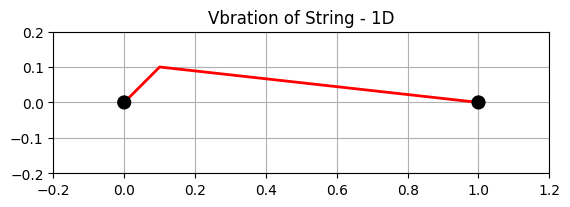

In [67]:
## create a static image
figure=plt.figure()
ax=figure.add_subplot(aspect='equal')
ax.set_title("Vbration of String - 1D")
ax.set_xlim(-0.2,1.2)
ax.set_ylim(-0.2,0.2)
ax.grid()
ax.plot(x,unext,linewidth=2,color='r')
ax.add_patch(plt.Circle([0,0],radius=0.02,facecolor='k',zorder=2))
ax.add_patch(plt.Circle([1,0],radius=0.02,facecolor='k',zorder=3))

plt.savefig("Vibration_of_String.jpg")
plt.show()


In [69]:
## solve the differential equation
for t in range(0,nt):
    for ui in range(1,100):
        u=(((((deltat**2)*(T))/(deltax**2)*(munot)))*((unow[ui+1])-(2*unow[ui])+(unow[ui-1]))-(uprevious[ui])+(2*(unow[ui])))- (((0.5*beta*(deltat**2))/(munot))*(unow[ui]+uprevious[ui]))
        unext[ui]=u
        #print(unext)
    uprevious=unow.copy()
    unow=unext.copy()
    u_y.append(unow)

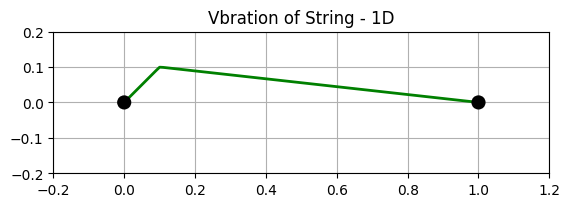

In [71]:
## create video
fig=plt.figure()
ax1=fig.add_subplot(aspect='equal')
ax1.set_title("Vbration of String - 1D")
ax1.set_xlim(-0.2,1.2)
ax1.set_ylim(-0.2,0.2)
ax1.grid()

string,=ax1.plot(x,unext,linewidth=2,color='g')
ax1.add_patch(plt.Circle([0,0],radius=0.02,facecolor='k',zorder=2))
ax1.add_patch(plt.Circle([1,0],radius=0.02,facecolor='k',zorder=3))

def animate(i):
    string.set_data([x,u_y[i]])

anim=animation.FuncAnimation(fig,animate,frames=nt)
ffmpeg_writer=animation.FFMpegWriter(fps=30)
anim.save("Vibration_of_String_1D.mp4",writer=ffmpeg_writer)
anim.save('Vibration_of_string.gif',writer=ffmpeg_writer)

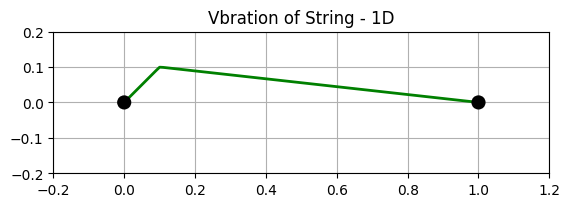

In [72]:
fig1=plt.figure()
ax1=fig1.add_subplot(aspect='equal')
ax1.set_title("Vbration of String - 1D")
ax1.set_xlim(-0.2,1.2)
ax1.set_ylim(-0.2,0.2)
ax1.grid()

string1,=ax1.plot(x,u_ic,linewidth=2,color='g')
ax1.add_patch(plt.Circle([0,0],radius=0.02,facecolor='k',zorder=2))
ax1.add_patch(plt.Circle([1,0],radius=0.02,facecolor='k',zorder=3))

def animate_fast(i):

    string1.set_data(x,u_y[i*2])


anim_speed=animation.FuncAnimation(fig1,animate_fast,frames=range(0,nt,10))
ffmpeg_writer=animation.FFMpegWriter(fps=120)
anim.save("Vibration_of_String_1D_fast.mp4",writer=ffmpeg_writer)
anim.save('Vibration_of_string_fast.gif',writer=ffmpeg_writer)